# Краткость — сестра таланта?

«Краткость — сестра таланта» — фраза Чехова из письма брату Александру.
Проверяем, следовал ли он ей сам: **короче ли предложения у Чехова, чем у других?**

Сравниваем четырёх авторов: Чехова, Горького, Брюсова и Толстого.
Горький и Брюсов — современники Чехова: они нужны, чтобы отличить личную манеру
от свойства эпохи и жанра.

## Настройка

Один раз задаём всё, на чём держится анализ: кого сравниваем и что не берём
в подсчёт. Все решения — наверху, чтобы их было видно сразу.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from razdel import sentenize

# Корпус лежит в data/raw (скачан командой git clone)
RAW = Path("data/raw/prose")

AUTHORS = ["Chekhov", "Gorky", "Bryusov", "Tolstoy"]
LABELS = {"Chekhov": "Чехов", "Gorky": "Горький",
          "Bryusov": "Брюсов", "Tolstoy": "Толстой"}

# Считаем только повествовательную прозу: пьеса, публицистика, очерк и поэма
# в прозе — другой тип речи. Исключаем поимённо, с причиной у каждого текста.
EXCLUDED = {
    ("Chekhov", "Три сестры"): "пьеса",
    ("Chekhov", "Вишнёвый сад"): "пьеса",
    ("Gorky", "Мещане"): "пьеса",
    ("Gorky", "На дне"): "пьеса",
    ("Gorky", "Несвоевременные мысли"): "публицистика",
    ("Gorky", "Город жёлтого дьявола"): "очерк",
    ("Gorky", "Сказки об Италии"): "очерк",
    ("Gorky", "Человек"): "поэма в прозе",
}

# Короткие тексты не берём: на паре десятков предложений среднее — шум.
MIN_SENTENCES = 50

for (author, title), reason in EXCLUDED.items():
    print(f"{LABELS[author]:8} {title:26} — не берём: {reason}")

Чехов    Три сестры                 — не берём: пьеса
Чехов    Вишнёвый сад               — не берём: пьеса
Горький  Мещане                     — не берём: пьеса
Горький  На дне                     — не берём: пьеса
Горький  Несвоевременные мысли      — не берём: публицистика
Горький  Город жёлтого дьявола      — не берём: очерк
Горький  Сказки об Италии           — не берём: очерк
Горький  Человек                    — не берём: поэма в прозе


## Длина предложения

Границы предложений размечает `razdel` — библиотека из проекта
[Natasha](https://natasha.github.io/), сделанная под русский язык. Делить текст
по точке нельзя: разбиение ломается на сокращениях («и т. д.») и инициалах.

In [2]:
def sentence_lengths(text):
    """Длины предложений в словах."""
    return [len(s.text.split()) for s in sentenize(text) if s.text.split()]

## Собираем таблицу

Считаем **по произведениям, а не по предложениям**: иначе «Война и мир» (треть
всех предложений Толстого) перевесила бы всё остальное. Берём каждый текст
отдельно, считаем среднюю длину предложения внутри него — и сравниваем авторов
уже по этим числам.

In [3]:
rows = []
for author in AUTHORS:
    for path in sorted((RAW / author).glob("*.txt")):
        title = path.stem
        if (author, title) in EXCLUDED:
            continue
        lengths = sentence_lengths(path.read_text(encoding="utf-8"))
        if len(lengths) < MIN_SENTENCES:
            continue
        rows.append({
            "author": author,
            "title": title,
            "n_sentences": len(lengths),
            "mean_sentence_len": round(sum(lengths) / len(lengths), 2),
        })

works = pd.DataFrame(rows)

# Сохраняем результат. Папку data/processed код создаёт сам, если её нет.
out = Path("data/processed")
out.mkdir(parents=True, exist_ok=True)
works.to_csv(out / "works.csv", index=False, encoding="utf-8")

works.head()

,author,title,n_sentences,mean_sentence_len
0,Chekhov,Агафья,284,10.95
1,Chekhov,Анна на шее,206,19.57
2,Chekhov,Анюта,123,9.80
3,Chekhov,Аптекарша,182,8.20
4,Chekhov,Ариадна,482,17.52


## Результат

In [4]:
summary = pd.DataFrame({
    "Произведений": works.groupby("author").size(),
    "Средняя длина": works.groupby("author")["mean_sentence_len"].mean().round(1),
    "Медиана": works.groupby("author")["mean_sentence_len"].median().round(1),
}).reindex(AUTHORS)
summary.index = [LABELS[a] for a in summary.index]
summary

,Произведений,Средняя длина,Медиана
Чехов,73,11.0,10.8
Горький,25,11.6,11.0
Брюсов,30,14.5,14.0
Толстой,42,15.3,15.0


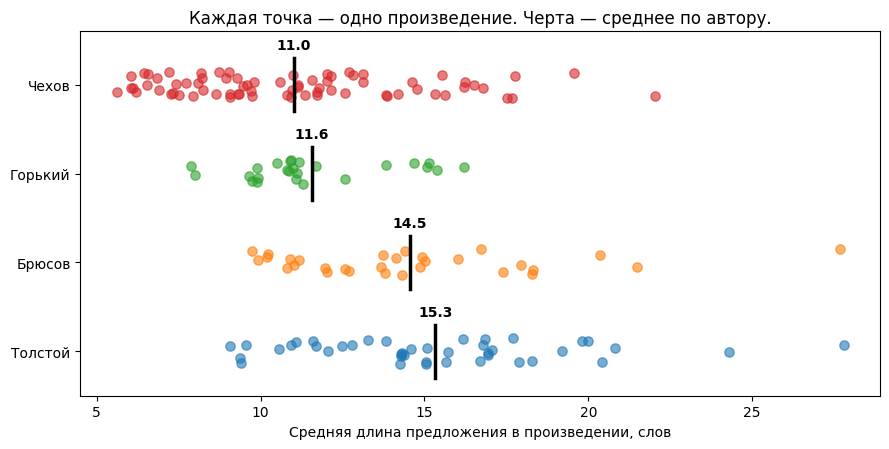

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.6))

for i, author in enumerate(reversed(AUTHORS)):
    values = works.loc[works.author == author, "mean_sentence_len"]
    # разброс по вертикали, чтобы точки не сливались в одну линию
    y = np.random.uniform(i - 0.15, i + 0.15, len(values))
    ax.scatter(values, y, s=45, alpha=0.6)
    ax.plot([values.mean()] * 2, [i - 0.3, i + 0.3], lw=2.5, color="black")
    ax.text(values.mean(), i + 0.4, f"{values.mean():.1f}",
            ha="center", fontweight="bold")

ax.set_yticks(range(len(AUTHORS)), [LABELS[a] for a in reversed(AUTHORS)])
ax.set_xlabel("Средняя длина предложения в произведении, слов")
ax.set_ylim(-0.5, len(AUTHORS) - 0.4)   # запас сверху, чтобы подписи не налезали
ax.set_title("Каждая точка — одно произведение. Черта — среднее по автору.")
plt.tight_layout()

Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/sentence_length.png", dpi=150)
plt.show()

Чехов действительно самый краткий из четырёх. Но выводы делаем осторожно: точки
на графике широко пересекаются — у Чехова есть тексты длиннее среднего Толстого,
у Толстого короче среднего Чехова. Это утверждение про средние, а не про каждый
текст.